**M5-KMeans Clustering Model**

•	Develop a k-means multivariate clustering model for three clusters (k=3)

•	Compare the cluster memberships to the actual class labels. How accurate is the clustering algorithm? (Hint: here you will compare the cluster labels of all data points to their actual labels, which you can do by using a two-column side-by-side comparison in Excel).


In [5]:
from google.colab import files
uploaded=files.upload()

Saving iris.data to iris (1).data


I used Pandas to load the Iris dataset and assigned names to the five columns. Then, I used df.head() to display the first five rows and check the data.

In [11]:
import pandas as pd
column_names=('sepal_length','sepal_width','petal_length','petal_width','class')
df=pd.read_csv('iris.data',names=column_names)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**checking the dataset**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Preparing the Features**




In [13]:
x=df.drop('class',axis=1)
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


**Building the K-Means Model**

In [31]:
from sklearn.cluster import KMeans
KMeans=KMeans(n_clusters=3,random_state=42)
KMeans.fit(x)

KMeans(n_clusters=3, random_state=42)

**comparing actual label and cluster memberships**

In [35]:
df['cluster']=KMeans.labels_
df[['class','cluster']].head(10)

,class,cluster
0,Iris-setosa,1
1,Iris-setosa,1
2,Iris-setosa,1
3,Iris-setosa,1
4,Iris-setosa,1
5,Iris-setosa,1
6,Iris-setosa,1
7,Iris-setosa,1
8,Iris-setosa,1
9,Iris-setosa,1


**comparing clusters with actual classes**

In [36]:
comparison = pd.crosstab(df['class'], df['cluster'])

comparison

cluster,0,1,2
class,,,
Iris-setosa,0,50,0
Iris-versicolor,3,0,47
Iris-virginica,36,0,14


**clustering accuracy**

In [37]:
correct = comparison.max(axis=0).sum()
total = len(df)
accuracy = correct / total

print("Correctly clustered:", correct)
print("Total observations:", total)
print("Clustering accuracy:", round(accuracy * 100, 2), "%")

Correctly clustered: 133
Total observations: 150
Clustering accuracy: 88.67 %


**Visualization**

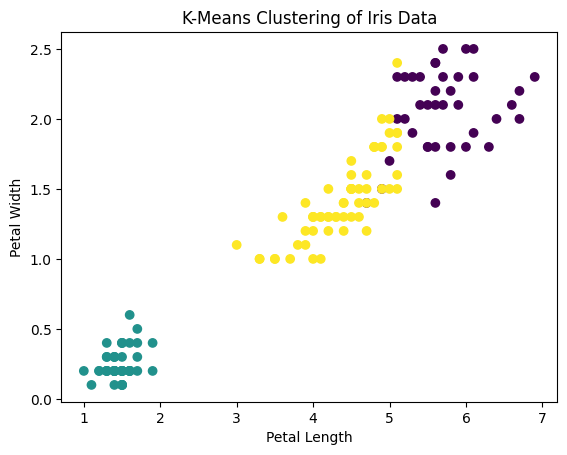

In [38]:
import matplotlib.pyplot as plt

plt.scatter(df['petal_length'], df['petal_width'],
            c=df['cluster'])

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clustering of Iris Data')

plt.show()